# ARC DXF Pipeline — Step by Step
Questo notebook esegue la pipeline di split e iniezione dati su un file DXF, visualizzando ogni passaggio.

---
## 0 · Setup & Configurazione

In [2]:
import ezdxf
import dxf_forge as forge
import os, re, json
from collections import Counter


import matplotlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ezdxf.addons.drawing import RenderContext, Frontend
from ezdxf.addons.drawing.matplotlib import MatplotlibBackend

from IPython.display import display
import pandas as pd

from dxf_forge.text_utils import clean_mtext
from dxf_forge.exporter import build_metadata

# ──────────────────────────────────────────────
# ← CAMBIA QUI con il tuo file
INPUT_DXF = r"c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo.dxf"
# ──────────────────────────────────────────────

OUTPUT_DIR = os.path.join(
    os.path.dirname(INPUT_DXF),
    os.path.splitext(os.path.basename(INPUT_DXF))[0]
)
LABEL = os.path.splitext(os.path.basename(INPUT_DXF))[0].replace(" Sviluppo", "")

os.makedirs(OUTPUT_DIR, exist_ok=True)


print(f"Input : {INPUT_DXF}")
print(f"Output: {OUTPUT_DIR}")
print(f"Label : {LABEL}")

Input : c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo.dxf
Output: c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo
Label : 6200012810


---
## 1 · Apertura del DXF

In [3]:
doc = ezdxf.readfile(INPUT_DXF)


if doc.dxfversion < 'AC1015':
    print("Versione DXF < R2000 — upgrade a R2010...")
    doc = forge.upgrade_to_r2010(doc)
    print("  Upgrade completato.")
else:
    print(f"Versione DXF: {doc.dxfversion} — nessun upgrade necessario.")

msp = doc.modelspace()
print(f"Modelspace caricato: {sum(1 for _ in msp)} entità totali")

Versione DXF: AC1021 — nessun upgrade necessario.
Modelspace caricato: 43 entità totali


---
## 2 · Ispezione entità nel Modelspace

In [4]:
# Conteggio per tipo
types = Counter(e.dxftype() for e in msp)
df_types = pd.DataFrame(
    sorted(types.items(), key=lambda x: -x[1]),
    columns=["Tipo entità", "Conteggio"]
)
print("Entità nel Modelspace:")
display(df_types.style.bar(subset=["Conteggio"], color="#4C8BF5").hide(axis="index"))

Entità nel Modelspace:


Tipo entità,Conteggio
INSERT,22
MULTILEADER,16
DIMENSION,5


In [5]:
# Ispezione degli INSERT (blocchi annidati)
insert_data = []
for e in msp:
    if e.dxftype() == 'INSERT':
        try:
            block = doc.blocks.get(e.dxf.name)
            inner = Counter(sub.dxftype() for sub in block)
            insert_data.append({"Block name": e.dxf.name, **inner})
        except Exception as ex:
            insert_data.append({"Block name": e.dxf.name, "ERRORE": str(ex)})

if insert_data:
    df_inserts = pd.DataFrame(insert_data).fillna(0)
    # converti colonne numeriche a int
    for col in df_inserts.columns[1:]:
        try:
            df_inserts[col] = df_inserts[col].astype(int)
        except:
            pass
    print(f"\nINSERT trovati: {len(insert_data)}")
    display(df_inserts.style.hide(axis="index"))
else:
    print("Nessun INSERT nel modelspace.")


INSERT trovati: 22


Block name,MTEXT,LINE,INSERT,CIRCLE,ARC
SEANNOT_GROUP,0,0,0,0,0
SEANNOT_GROUP1,0,0,0,0,0
SEANNOT_GROUP2,0,0,0,0,0
SEANNOT_GROUP3,0,0,0,0,0
SEANNOT_GROUP4,0,0,0,0,0
SEANNOT_GROUP5,0,0,0,0,0
SEANNOT_GROUP6,0,0,0,0,0
SEANNOT_GROUP7,0,0,0,0,0
SEANNOT_GROUP8,0,0,0,0,0
SEANNOT_GROUP9,0,0,0,0,0


---
## 3 · Rendering del DXF originale

Rendering del file originale...


2 extra bytes in post.stringData array


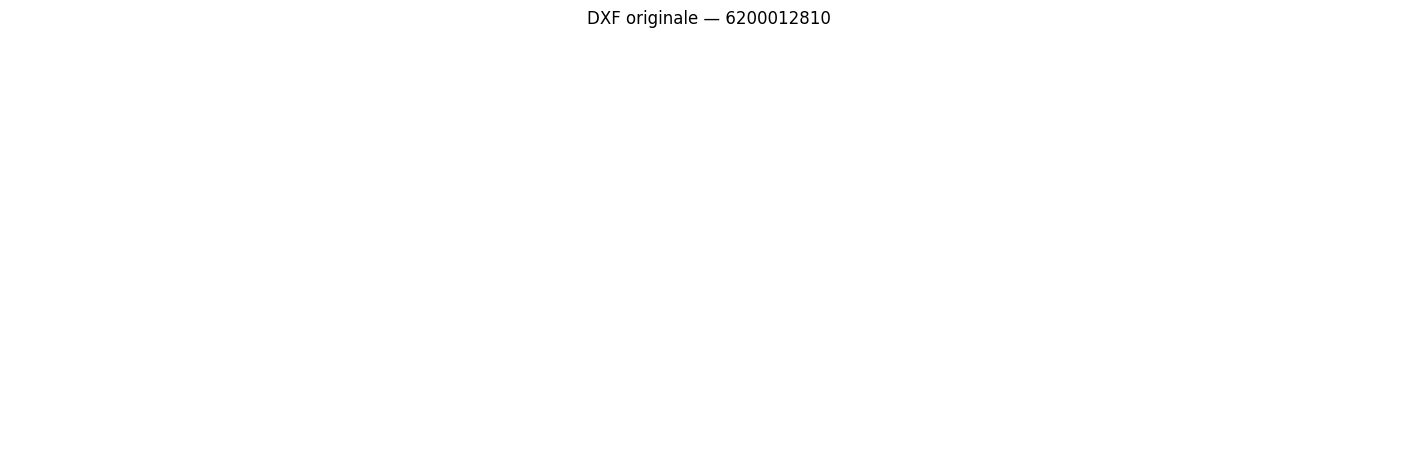

In [6]:
def render_layout(layout, doc, title="", figsize=(14, 10)):
    """Renderizza un layout DXF con ezdxf drawing addon."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal')
    ctx = RenderContext(doc)
    backend = MatplotlibBackend(ax)
    Frontend(ctx, backend).draw_layout(layout)
    if title:
        ax.set_title(title, fontsize=12, pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("Rendering del file originale...")
render_layout(msp, doc, title=f"DXF originale — {LABEL}")

---
## 4 · Validazione

In [7]:
check = forge.validate_msp(msp)

if check.warnings:
    print(f"⚠️  Warning ({len(check.warnings)}):")
    for w in check.warnings:
        print(f"   • {w}")
else:
    print("✅ Nessun warning")

if check.errors:
    print(f"\n❌ Errori bloccanti ({len(check.errors)}):")
    for e in check.errors:
        print(f"   • {e}")
    raise RuntimeError("Errori bloccanti nel DXF — interrompo la pipeline.")
else:
    print("✅ Nessun errore bloccante — si può procedere")

⚠️  Warning (1):
   • Trovati 22 INSERT (blocchi). Usa explode_inserts=True in heal() per esploderli.
✅ Nessun errore bloccante — si può procedere


---
## 5 · Estrazione materiale dal cartiglio

In [8]:
def estrai_materiale(doc) -> str:
    for block in doc.blocks:
        if 'cartiglio' in block.name.lower():
            for e in block:
                if e.dxftype() == 'MTEXT':
                    txt = clean_mtext(e.text)
                    if 'materiale' in txt.lower():
                        return txt.split(':', 1)[-1].strip()
    return "N/D"

materiale = estrai_materiale(doc)
print(f"Materiale estratto dal cartiglio: '{materiale}'")

# Debug: mostra i blocchi con 'cartiglio' nel nome
cartigli = [b.name for b in doc.blocks if 'cartiglio' in b.name.lower()]
if cartigli:
    print(f"Blocchi cartiglio trovati: {cartigli}")
else:
    print("⚠️  Nessun blocco con 'cartiglio' nel nome — materiale = N/D")

Materiale estratto dal cartiglio: 'S235JR EN 10025'
Blocchi cartiglio trovati: ['Cartiglio_sviluppo']


---
## 6 · Definizione parser e data injector

In [9]:
PATTERNS = {
    "codice":   r'cod(?:ice)?\s*[:\-]?\s*(\S+)',
    "spessore": r'spes(?:sore)?\s*[:\-]?\s*([\d.,]+)',
    "materiale":r'mat(?:eriale)?\s*[:\-]?\s*(.+)',
    "quantity": r'pez(?:zi)[^\d]*([\d]+)',
}

def parse_testi(testi: list) -> dict:
    info = {"codice": "", "thickness": 0.0, "quantity": 1, "material": "N/D"}
    righe = []
    for t in testi:
        righe.extend(t.splitlines())
    righe = [r.strip() for r in righe if r.strip()]
    blob = '\n'.join(righe)
    for key, pattern in PATTERNS.items():
        m = re.search(pattern, blob, re.IGNORECASE)
        if m:
            val = m.group(1).strip()
            if key == "codice":    info["codice"]    = val
            elif key == "spessore":info["thickness"] = float(val.replace(',', '.').split()[0])
            elif key == "materiale":info["material"] = val
            elif key == "quantity":info["quantity"]  = int(val)
    return info

def sanitize_filename(name: str) -> str:
    name = name.strip()
    name = re.sub(r'[\\/:"*?<>|\n\r\t]', '_', name)
    name = re.sub(r'_+', '_', name)
    name = name.strip('_.')
    return name or "UNNAMED"

def make_data_injector(doc):
    mat = estrai_materiale(doc)
    def data_injector(part, testi) -> dict:
        info = parse_testi(testi)
        return {
            "material" : mat,
            "thickness": info["thickness"],
            "quantity" : info["quantity"],
            "_codice"  : info["codice"],
        }
    return data_injector

print("✅ Parser e injector definiti")

✅ Parser e injector definiti


---
## 7 · Split in pezzi separati

In [10]:
print(f"Avvio split → {OUTPUT_DIR}\n")

result = forge.split_to_files(
    msp,
    output_folder=OUTPUT_DIR,
    tolerance=2,
    explode_inserts=True,
    label=LABEL,
    source_file=INPUT_DXF,
    include_annotations=True,
    data_injector=make_data_injector(doc),
    namer=lambda i, part: sanitize_filename(
        part.custom.get("_codice") or f"{LABEL}_PART{i}"
    ),
)

print(f"\n✅ Split completato: {len(result.parts)} pezzi trovati")

Avvio split → c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo

  [WRITE] LWPOLYLINE layer=OuterContour area=4400.0
  [WRITE] LWPOLYLINE layer=OuterContour area=629542.1
  [WRITE] LWPOLYLINE layer=OuterContour area=1586.2
  [WRITE] LWPOLYLINE layer=OuterContour area=348277.5
  [WRITE] LWPOLYLINE layer=OuterContour area=1925.0
  [WRITE] LWPOLYLINE layer=OuterContour area=6169.7
  [WRITE] LWPOLYLINE layer=InnerContour area=38.4
  [WRITE] LWPOLYLINE layer=InnerContour area=38.4
  [WRITE] LWPOLYLINE layer=InnerContour area=36.8
  [WRITE] LWPOLYLINE layer=InnerContour area=36.8
  [heal] 22 INSERT esplosi prima dell'healing.

✅ Split completato: 6 pezzi trovati


---
## 8 · Riepilogo pezzi — tabella

In [11]:
rows = []
for part in result.parts:
    rows.append({
        "Label"     : part.label,
        "Codice"    : part.custom.get("_codice", ""),
        "Materiale" : part.custom.get("material", ""),
        "Spessore"  : part.custom.get("thickness", ""),
        "Quantità"  : part.custom.get("quantity", ""),
    })

df_parts = pd.DataFrame(rows)
print(f"Pezzi estratti: {len(df_parts)}")
display(df_parts.style.hide(axis="index"))

Pezzi estratti: 6


Label,Codice,Materiale,Spessore,Quantità
6200012810_2,6200012810_2,S235JR EN 10025,2.000000,1
6200012810_3,6200012810_3,S235JR EN 10025,2.000000,1
6200012810_5,6200012810_5,S235JR EN 10025,2.000000,1
6200012810_PART4,,S235JR EN 10025,0.000000,1
6200012810_4,6200012810_4,S235JR EN 10025,10.000000,4
6200012810_1,6200012810_1,S235JR EN 10025,10.000000,2


---
## 9 · Rendering di ogni pezzo

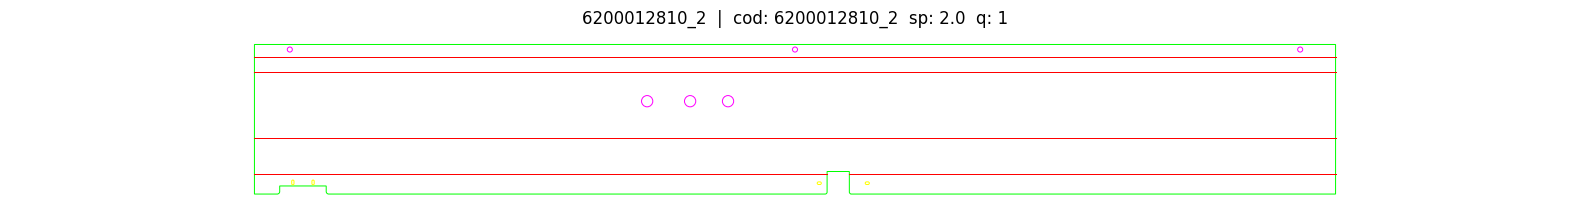

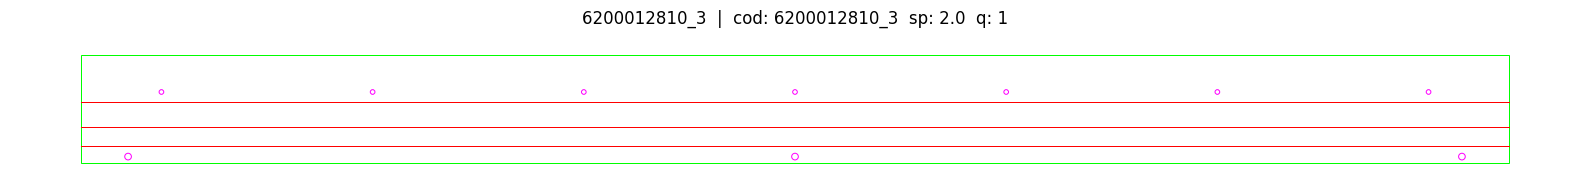

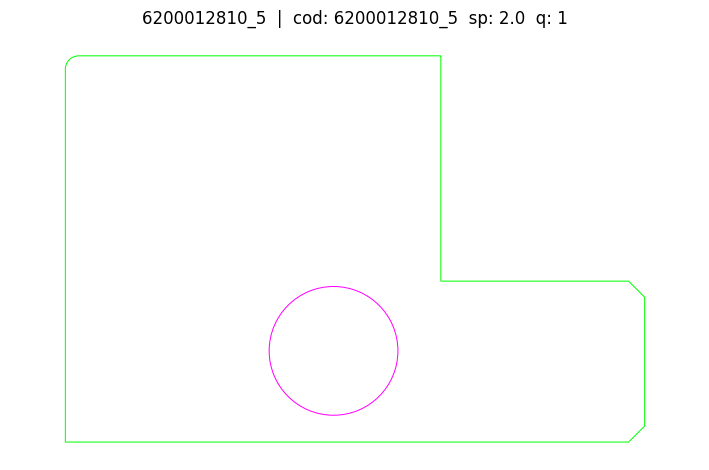

  ❌ Errore rendering 6200012810_PART4: Required block definition for "DVK_logo_sviluppi" does not exist.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


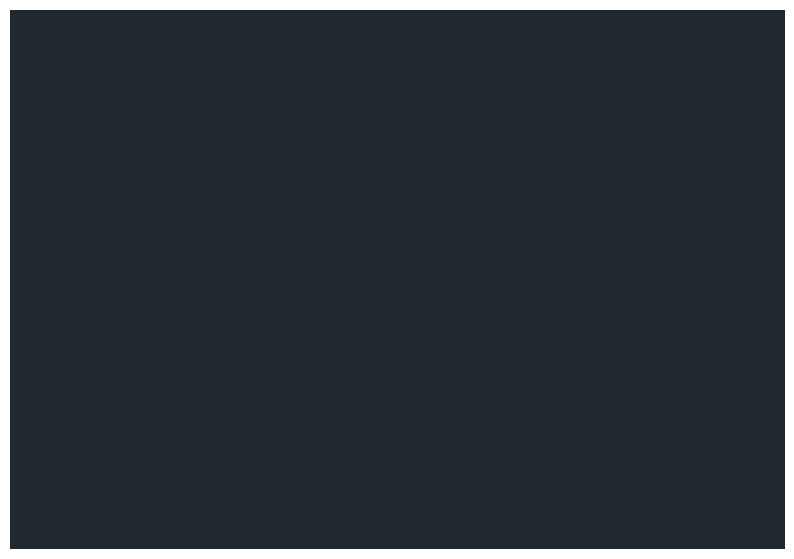

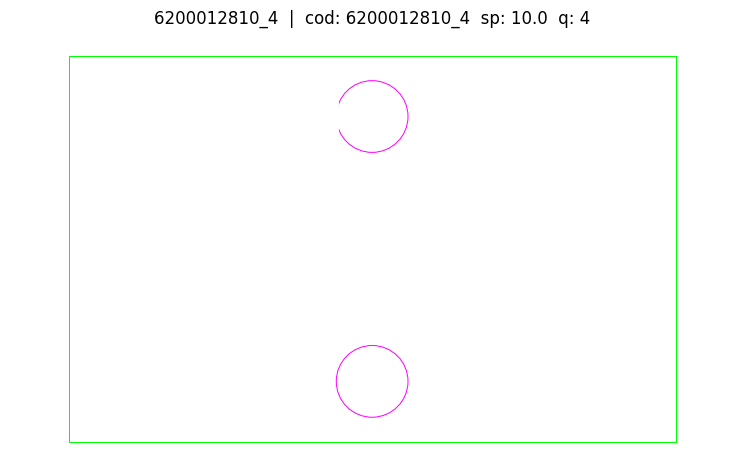

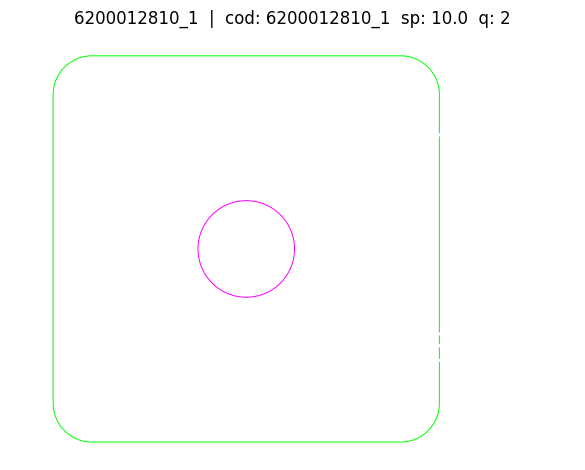

In [12]:
for part in result.parts:
    filepath = os.path.join(OUTPUT_DIR, f"{part.label}.dxf")
    if not os.path.exists(filepath):
        print(f"  ⚠️  File non trovato: {filepath}")
        continue
    try:
        child_doc = ezdxf.readfile(filepath)
        child_msp = child_doc.modelspace()
        codice    = part.custom.get('_codice', '—')
        spessore  = part.custom.get('thickness', '—')
        quantita  = part.custom.get('quantity', '—')
        titolo    = f"{part.label}  |  cod: {codice}  sp: {spessore}  q: {quantita}"
        render_layout(child_msp, child_doc, title=titolo, figsize=(10, 7))
    except Exception as ex:
        print(f"  ❌ Errore rendering {part.label}: {ex}")

---
## 10 · Export JSON per pezzo + metadati globali

In [13]:
salvati = []
errori  = []

for part in result.parts:
    filepath = os.path.join(OUTPUT_DIR, f"{part.label}.dxf")
    try:
        child_doc = ezdxf.readfile(filepath)
        child_doc.saveas(filepath)

        meta = build_metadata(part)
        json_path = os.path.join(OUTPUT_DIR, f"{part.label}.json")
        with open(json_path, 'w', encoding='utf-8') as f:
            json.dump(meta, f, indent=2, ensure_ascii=False)
        salvati.append(part.label)
    except Exception as ex:
        errori.append((part.label, str(ex)))

# Metadati globali
global_json = os.path.join(OUTPUT_DIR, "split_metadata.json")
forge.save_json(result, global_json)

print(f"✅ Salvati: {len(salvati)} pezzi")
if errori:
    print(f"❌ Errori ({len(errori)}):")
    for label, msg in errori:
        print(f"   • {label}: {msg}")
print(f"\nMetadati globali: {global_json}")
print(f"Output dir      : {OUTPUT_DIR}")

[forge] JSON salvato in c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo\split_metadata.json
✅ Salvati: 6 pezzi

Metadati globali: c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo\split_metadata.json
Output dir      : c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo


---
## 11 · Summary finale

In [14]:
print("═" * 50)
print(" PIPELINE COMPLETATA")
print("═" * 50)
print(f"  File sorgente : {os.path.basename(INPUT_DXF)}")
print(f"  Pezzi trovati : {len(result.parts)}")
print(f"  Materiale     : {materiale}")
print(f"  Output dir    : {OUTPUT_DIR}")
print()

# Elenco file prodotti
files = sorted(os.listdir(OUTPUT_DIR))
dxf_files  = [f for f in files if f.endswith('.dxf')]
json_files = [f for f in files if f.endswith('.json')]
print(f"  DXF  generati : {len(dxf_files)}")
print(f"  JSON generati : {len(json_files)}")

df_final = pd.DataFrame(rows)
display(df_final.style.hide(axis="index"))

══════════════════════════════════════════════════
 PIPELINE COMPLETATA
══════════════════════════════════════════════════
  File sorgente : 6200012810 Sviluppo.dxf
  Pezzi trovati : 6
  Materiale     : S235JR EN 10025
  Output dir    : c:\Users\FEDERICO\Documents\Python_Scripts\Projects\DXF\ARC - Copia\ARC.6200012810 Sviluppo\6200012810 Sviluppo

  DXF  generati : 6
  JSON generati : 7


Label,Codice,Materiale,Spessore,Quantità
6200012810_2,6200012810_2,S235JR EN 10025,2.000000,1
6200012810_3,6200012810_3,S235JR EN 10025,2.000000,1
6200012810_5,6200012810_5,S235JR EN 10025,2.000000,1
6200012810_PART4,,S235JR EN 10025,0.000000,1
6200012810_4,6200012810_4,S235JR EN 10025,10.000000,4
6200012810_1,6200012810_1,S235JR EN 10025,10.000000,2
